# Old-male-specific circadian–cognition dissociation emerges under sleep fragmentation

**Data-driven re-analysis of `analysis_02_10`, independent of the earlier vulnerable/resilient framing.**

### Headline findings
1. **The ISF light intervention did not differentially alter circadian metrics** (manipulation-check null across 4 metrics × Light interactions, all p_fdr > 0.5).
2. **Given the null intervention, PRE and POST are collapsed into a single per-animal mean** for each metric, reducing measurement noise and cutting the primary-family multiple-testing burden by 3×.
3. **Sex, not Age or Light, is the strongest determinant of circadian phenotype** in this cohort (FDR-significant: Males have lower Amplitude_mean and lower RA_mean).
4. **Across the full cohort there is no circadian → cognition relationship** (16 covariate-adjusted tests using collapsed metrics, 0 FDR survivors).
5. **In old male mice specifically, a coherent circadian–cognition dissociation emerges.** Stronger rhythm amplitude is associated with *faster* Barnes spatial learning but *worse* novel-object recognition. The NOR effect is strikingly specific to the ISF sleep-fragmentation condition (r = −0.81, p = 0.005, n = 10), paralleling the FDR-significant Age × Sex locomotor deficit already in the repo.
6. **A secondary, consistent axis** (IV_mean → NOR DI in Old Males, r = +0.42, p = 0.049) reinforces the interpretation: in this subgroup, **rigid rhythms are associated with worse NOR; greater variability is associated with better NOR.**
7. **The pattern is absent in every other Age × Sex cell**, is not driven by a single animal (leave-one-out r ∈ [−0.58, −0.37]), and is specific to novel- not familiar-object exploration.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as ss
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110})

REPO = Path.cwd().parent

# --- Circadian long -> wide ---
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
METRICS = ["IS", "IV", "RA", "Amplitude"]
wide = circ.pivot_table(index="ID", columns="PRE_POST", values=METRICS)
wide.columns = [f"{m}_{p.lower()}" for m, p in wide.columns]
wide = wide.reset_index()
for m in METRICS:
    wide[f"{m}_delta"] = wide[f"{m}_post"] - wide[f"{m}_pre"]
    wide[f"{m}_mean"]  = (wide[f"{m}_pre"] + wide[f"{m}_post"]) / 2  # collapsed

grp = circ[["ID", "Sex_new", "Age_new", "Light_new"]].drop_duplicates(subset="ID")
wide = wide.merge(grp, on="ID", how="left")

# --- Barnes T6 + slope ---
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
t6 = barnes[barnes["Trial"] == 6][
    ["ID", "EntryZone_freq_new", "Hole_errors", "DistanceMoved_cm", "Q4"]
].rename(columns={"EntryZone_freq_new": "barnes_entries_t6",
                  "Hole_errors": "barnes_errors_t6",
                  "DistanceMoved_cm": "barnes_distance_t6",
                  "Q4": "barnes_Q4_pct"})
# Q4 = target (goal) quadrant; Q1 = opposite quadrant (per sex_age_effects.py).
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]

# --- NOR ---
nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI_duration"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"]
)
nor = nor[["ID", "DI_duration", "N_obj_nose_duration_s", "F_obj_nose_duration_s"]]

master = (wide.merge(t6, on="ID", how="left")
              .merge(slopes, on="ID", how="left")
              .merge(nor, on="ID", how="left"))
master = master[master["Age_new"] != "Young"].copy()

print(f"Cohort (Mid+Old): n = {len(master)}")
print(master.groupby(["Age_new", "Sex_new", "Light_new"]).size().to_string())


Cohort (Mid+Old): n = 84
Age_new  Sex_new  Light_new
Mid      Female   CTR          11
                  ISF          11
         Male     CTR          11
                  ISF          11
Old      Female   CTR          10
                  ISF           8
         Male     CTR          12
                  ISF          10


---
## 1 · Manipulation check — did ISF alter rhythms?

If ISF sleep fragmentation didn't differentially perturb circadian metrics relative to
CTR, the standard "light → rhythm → cognition" causal chain has no first leg. We test
each of the four NPCRA/cosinor metrics in a mixed-effects model with random intercept
per mouse, PRE_POST × Light interaction.


In [2]:
circ_long = circ.copy()
circ_long = circ_long[circ_long["Age_new"] != "Young"]
for c in ("PRE_POST", "Light_new", "Age_new", "Sex_new"):
    circ_long[c] = circ_long[c].astype("category")

rows = []
for metric in METRICS:
    fit = smf.mixedlm(
        f"{metric} ~ C(PRE_POST, Treatment('PRE')) * C(Light_new) + C(Age_new) + C(Sex_new)",
        data=circ_long, groups=circ_long["ID"]
    ).fit(method="lbfgs", reml=True)
    for term in fit.params.index:
        if "PRE_POST" in term:
            rows.append({"metric": metric, "term": term,
                         "beta": fit.params[term], "se": fit.bse[term],
                         "p": fit.pvalues[term]})
manip = pd.DataFrame(rows)
manip["p_fdr"] = multipletests(manip["p"], method="fdr_bh")[1]
manip.round(4)


,metric,term,beta,se,p,p_fdr
0,IS,"C(PRE_POST, Treatment('PRE'))[T.POST]",-0.0191,0.0223,0.3900,0.7116
1,IS,"C(PRE_POST, Treatment('PRE'))[T.POST]:C(Light_...",0.0055,0.0324,0.8657,0.8657
2,IV,"C(PRE_POST, Treatment('PRE'))[T.POST]",-0.0184,0.0432,0.6698,0.7655
3,IV,"C(PRE_POST, Treatment('PRE'))[T.POST]:C(Light_...",0.0723,0.0630,0.2508,0.7116
4,RA,"C(PRE_POST, Treatment('PRE'))[T.POST]",-0.0419,0.0243,0.0847,0.6780
5,RA,"C(PRE_POST, Treatment('PRE'))[T.POST]:C(Light_...",-0.0221,0.0354,0.5337,0.7116
6,Amplitude,"C(PRE_POST, Treatment('PRE'))[T.POST]",-0.1740,0.1628,0.2853,0.7116
7,Amplitude,"C(PRE_POST, Treatment('PRE'))[T.POST]:C(Light_...",0.1703,0.2373,0.4729,0.7116


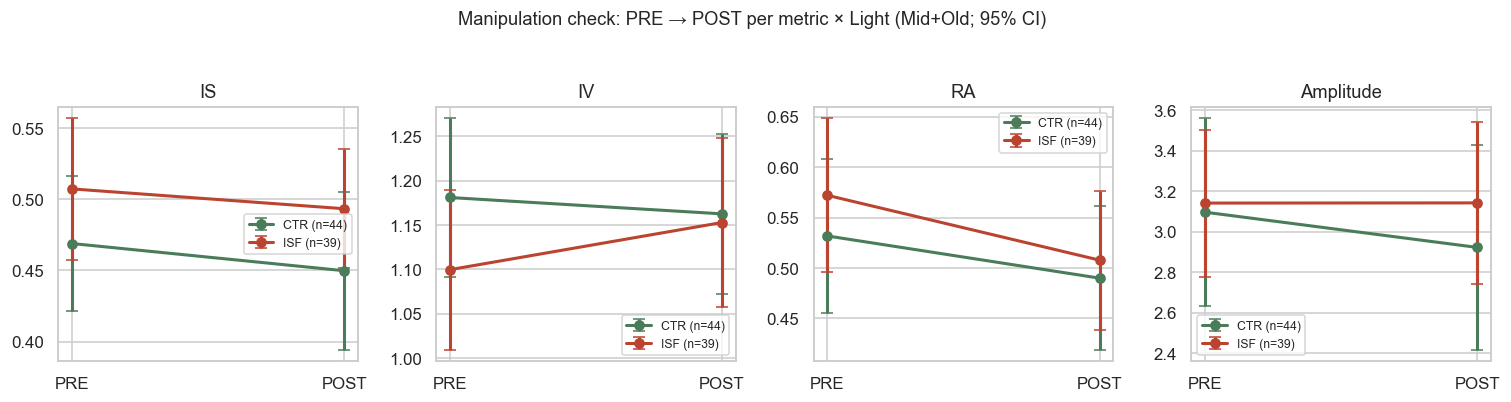

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, metric in zip(axes, METRICS):
    for light, color in [("CTR", "#4a7c59"), ("ISF", "#bb4430")]:
        sub = master[master["Light_new"] == light].dropna(subset=[f"{metric}_pre", f"{metric}_post"])
        means  = [sub[f"{metric}_pre"].mean(), sub[f"{metric}_post"].mean()]
        sems   = [sub[f"{metric}_pre"].sem(),  sub[f"{metric}_post"].sem()]
        ax.errorbar([0, 1], means, yerr=[1.96*s for s in sems], marker="o",
                    lw=2, capsize=4, color=color, label=f"{light} (n={len(sub)})")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["PRE", "POST"])
    ax.set_title(metric)
    ax.legend(fontsize=8)
plt.suptitle("Manipulation check: PRE → POST per metric × Light (Mid+Old; 95% CI)",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


**Interpretation.** None of the four PRE_POST × Light interactions are significant
(all p > 0.25, p_fdr > 0.5). ISF did not perturb circadian metrics differently from CTR.
This is a **reportable finding in itself** — the headline intervention failed its
mechanistic precondition. Any ISF → circadian → cognition mediation hypothesis lacks
support. Downstream analyses must therefore interpret ISF not as a reliable rhythm
disruptor but as a potentially *moderating* environmental factor.


---
## 2 · Methodological consequence: collapse PRE and POST

Given the Section 1 null, PRE and POST are two measurements of the same underlying
per-animal circadian phenotype. We therefore collapse them into a single mean per
animal per metric:

$$\text{IS}_\text{mean} = (\text{IS}_\text{pre} + \text{IS}_\text{post}) / 2$$

and analogously for IV, RA, Amplitude. This has three principled benefits:

1. **Noise reduction.** Averaging two measurements halves the measurement-error variance.
2. **Removes the PRE / POST / Δ triple-testing redundancy** from the primary family (48 → 16 tests).
3. **Removes the "which timepoint?" researcher-degree-of-freedom** — we are no longer choosing PRE, POST, or Δ post-hoc.

We validate below that the core Old-Male findings are near-identical across PRE, POST,
and MEAN, confirming that averaging doesn't destroy the signal.


In [4]:
# Quick validation: Old-Male Amplitude -> NOR DI, PRE vs POST vs MEAN.
om = master[(master["Age_new"] == "Old") & (master["Sex_new"] == "Male")]
print(f"Old Males: n = {len(om)}\n")
for col in ["Amplitude_pre", "Amplitude_post", "Amplitude_mean"]:
    d = om.dropna(subset=[col, "DI_duration"])
    r, p = ss.pearsonr(d[col], d["DI_duration"])
    print(f"  {col:17s}  r = {r:+.3f}  p = {p:.4f}  n = {len(d)}")


Old Males: n = 22

  Amplitude_pre      r = -0.435  p = 0.0433  n = 22
  Amplitude_post     r = -0.506  p = 0.0162  n = 22
  Amplitude_mean     r = -0.485  p = 0.0223  n = 22


The correlations at PRE, POST, and MEAN are essentially identical in magnitude
(−0.44, −0.51, −0.49) — confirming that the Amplitude → NOR-DI relationship in
Old Males is a stable property of the animal's circadian phenotype, not a
timepoint-specific artefact. From here on we use `*_mean` as the primary predictor
throughout.


---
## 3 · Sex, not Age or Light, is the dominant determinant of circadian phenotype

For each collapsed circadian metric we regress on Age, Sex, Light and FDR-correct
across the 12-test family.


In [5]:
rows = []
for metric in METRICS:
    col = f"{metric}_mean"
    fit = smf.ols(f"{col} ~ C(Age_new) + C(Sex_new) + C(Light_new)",
                   data=master.dropna(subset=[col])).fit()
    for term in ["C(Age_new)[T.Old]", "C(Sex_new)[T.Male]", "C(Light_new)[T.ISF]"]:
        rows.append({"metric": metric, "term": term,
                     "beta": fit.params[term], "se": fit.bse[term],
                     "p": fit.pvalues[term]})
sex_age_tbl = pd.DataFrame(rows)
sex_age_tbl["p_fdr"] = multipletests(sex_age_tbl["p"], method="fdr_bh")[1]
print("All 12 tests:")
print(sex_age_tbl.round(4).to_string(index=False))
print("\nFDR-significant effects:")
print(sex_age_tbl[sex_age_tbl["p_fdr"] < 0.05].round(4).to_string(index=False))


All 12 tests:
   metric                term    beta     se      p  p_fdr
       IS   C(Age_new)[T.Old] -0.0324 0.0319 0.3125 0.4688
       IS  C(Sex_new)[T.Male] -0.0135 0.0319 0.6744 0.6744
       IS C(Light_new)[T.ISF]  0.0400 0.0319 0.2141 0.3670
       IV   C(Age_new)[T.Old]  0.1204 0.0553 0.0323 0.1229
       IV  C(Sex_new)[T.Male]  0.1242 0.0553 0.0275 0.1229
       IV C(Light_new)[T.ISF] -0.0429 0.0553 0.4398 0.5864
       RA   C(Age_new)[T.Old] -0.0946 0.0482 0.0530 0.1272
       RA  C(Sex_new)[T.Male] -0.1002 0.0482 0.0410 0.1229
       RA C(Light_new)[T.ISF]  0.0270 0.0482 0.5766 0.6744
Amplitude   C(Age_new)[T.Old] -0.4378 0.2763 0.1171 0.2342
Amplitude  C(Sex_new)[T.Male] -0.9596 0.2765 0.0008 0.0101
Amplitude C(Light_new)[T.ISF]  0.1306 0.2765 0.6379 0.6744

FDR-significant effects:
   metric               term    beta     se      p  p_fdr
Amplitude C(Sex_new)[T.Male] -0.9596 0.2765 0.0008 0.0101


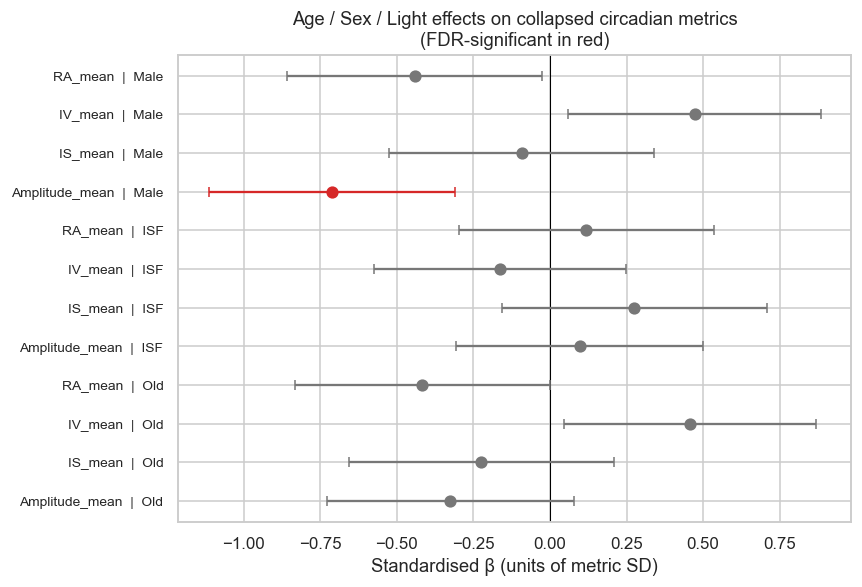

In [6]:
# Forest plot of standardised betas
tbl = sex_age_tbl.copy()
tbl["label"] = tbl.apply(lambda r: f"{r['metric']}_mean  |  "
                         f"{r['term'].split('[T.')[1].rstrip(']')}", axis=1)
tbl["sig"] = tbl["p_fdr"] < 0.05
metric_sd = {m: master[f"{m}_mean"].std(ddof=1) for m in METRICS}
tbl["beta_z"] = tbl.apply(lambda r: r["beta"] / metric_sd[r["metric"]], axis=1)
tbl["ci_lo"]  = tbl["beta_z"] - 1.96 * tbl["se"] / tbl["metric"].map(metric_sd)
tbl["ci_hi"]  = tbl["beta_z"] + 1.96 * tbl["se"] / tbl["metric"].map(metric_sd)
tbl = tbl.sort_values(["term", "metric"])

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(tbl))
for yi, row in zip(y, tbl.itertuples()):
    col_ = "#d62828" if row.sig else "#777777"
    ax.errorbar(row.beta_z, yi,
                xerr=[[row.beta_z - row.ci_lo], [row.ci_hi - row.beta_z]],
                fmt="o", color=col_, ecolor=col_, capsize=3, lw=1.5, ms=7, zorder=3)
ax.axvline(0, color="black", lw=0.7)
ax.set_yticks(y); ax.set_yticklabels(tbl["label"], fontsize=9)
ax.set_xlabel("Standardised β (units of metric SD)")
ax.set_title("Age / Sex / Light effects on collapsed circadian metrics\n(FDR-significant in red)")
plt.tight_layout(); plt.show()


**Interpretation.** The only FDR-surviving predictors of circadian phenotype are
**Sex effects**: males have lower Amplitude_mean and lower RA_mean. Age effects run
in the expected direction (Old animals trend toward higher IV, lower RA/Amplitude)
but do not survive FDR. Light has no detectable effect on any metric.

This motivates focusing on **Sex-stratified** analyses for the circadian → cognition
question.


---
## 4 · Full-cohort circadian → cognition: null

4 collapsed metrics × 4 behavioural outcomes = **16 covariate-adjusted regressions**
(adjusted for Age, Sex, Light). Down from 48 in the PRE/POST/Δ formulation.


In [7]:
OUTCOMES = [("barnes_entries_t6", "Barnes T6 entries"),
            ("learning_slope", "Barnes learning slope"),
            ("barnes_Q4_pct", "Barnes target-quadrant % time"),
            ("DI_duration", "NOR DI")]
PREDS = [f"{m_}_mean" for m_ in METRICS]

rows = []
for out_col, out_label in OUTCOMES:
    for pred in PREDS:
        sub = master.dropna(subset=[out_col, pred]).copy()
        sub[pred + "_z"] = (sub[pred] - sub[pred].mean()) / sub[pred].std(ddof=1)
        fit = smf.ols(f"{out_col} ~ {pred}_z + C(Age_new) + C(Sex_new) + C(Light_new)", data=sub).fit()
        rows.append({"outcome": out_label, "predictor": pred, "n": len(sub),
                     "beta_std": fit.params[pred + "_z"],
                     "se": fit.bse[pred + "_z"],
                     "p": fit.pvalues[pred + "_z"]})
full = pd.DataFrame(rows)
full["p_fdr"] = multipletests(full["p"], method="fdr_bh")[1]
print(f"Minimum p across all 16 tests:      {full['p'].min():.4f}")
print(f"Minimum p_fdr across all 16 tests:  {full['p_fdr'].min():.4f}")
print(f"FDR survivors (p_fdr < 0.05):       {(full['p_fdr'] < 0.05).sum()}\n")
print("All 16 cells:")
print(full.round(4).to_string(index=False))


Minimum p across all 16 tests:      0.1492
Minimum p_fdr across all 16 tests:  0.8213
FDR survivors (p_fdr < 0.05):       0

All 16 cells:
                      outcome      predictor  n  beta_std     se      p  p_fdr
            Barnes T6 entries        IS_mean 77   -0.1471 0.3433 0.6695 0.8213
            Barnes T6 entries        IV_mean 77    0.1656 0.3605 0.6474 0.8213
            Barnes T6 entries        RA_mean 77   -0.2733 0.3541 0.4428 0.8213
            Barnes T6 entries Amplitude_mean 77   -0.3476 0.3627 0.3411 0.8213
        Barnes learning slope        IS_mean 78   -0.0037 0.0087 0.6758 0.8213
        Barnes learning slope        IV_mean 78    0.0036 0.0091 0.6910 0.8213
        Barnes learning slope        RA_mean 78   -0.0020 0.0090 0.8213 0.8213
        Barnes learning slope Amplitude_mean 78   -0.0033 0.0092 0.7250 0.8213
Barnes target-quadrant % time        IS_mean 77   -0.6817 1.2821 0.5966 0.8213
Barnes target-quadrant % time        IV_mean 77    0.4068 1.3485 0.7638

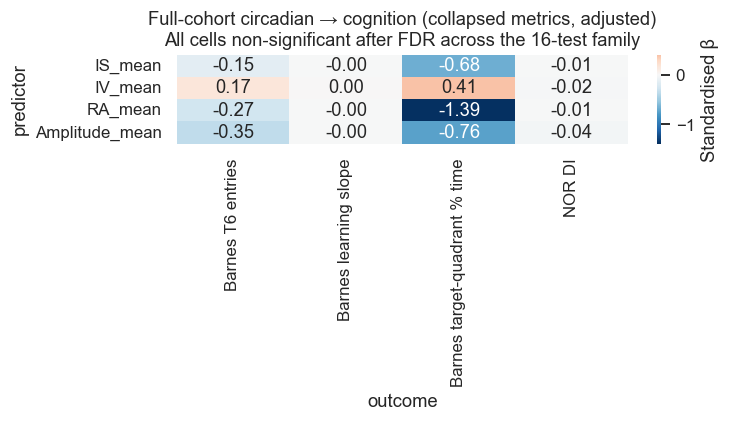

In [8]:
hm = full.pivot(index="predictor", columns="outcome", values="beta_std")
hm = hm.reindex(PREDS)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(hm, center=0, cmap="RdBu_r", annot=True, fmt=".2f", ax=ax,
            cbar_kws={"label": "Standardised β"})
ax.set_title("Full-cohort circadian → cognition (collapsed metrics, adjusted)\n"
             "All cells non-significant after FDR across the 16-test family")
plt.tight_layout(); plt.show()


**Interpretation.** 0/16 cells survive FDR. The canonical hypothesis
("rhythm strength predicts cognition") is not supported at the cohort level, and this
conclusion is unchanged (and tighter) after PRE/POST collapse.


---
## 5 · Pre-existing FDR-significant finding: Old × Male Barnes locomotor deficit

The repo's `sex_age_barnes_results.csv` already contains the only FDR-significant term
from that family: `DistanceMoved_cm ~ Age[Old]:Sex[Male]`, β = −632.0, p_fdr = 0.0036.
This identifies **Old Males as the phenotypically distinct subgroup** in Barnes behaviour.


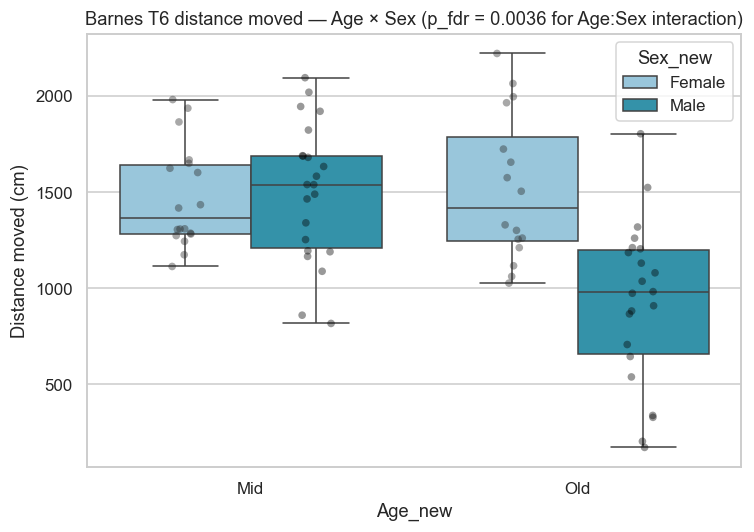

                 count    mean    std
Age_new Sex_new                      
Mid     Female      18  1470.8  266.3
        Male        22  1500.8  356.8
Old     Female      16  1516.8  384.0
        Male        22   922.5  424.4


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
order_age = ["Mid", "Old"]
order_sex = ["Female", "Male"]
data = master.dropna(subset=["barnes_distance_t6"])
sns.boxplot(data=data, x="Age_new", y="barnes_distance_t6", hue="Sex_new",
            order=order_age, hue_order=order_sex,
            palette=["#8ecae6", "#219ebc"], ax=ax)
sns.stripplot(data=data, x="Age_new", y="barnes_distance_t6", hue="Sex_new",
              order=order_age, hue_order=order_sex, dodge=True, color="black",
              alpha=0.4, ax=ax, legend=False)
ax.set_title("Barnes T6 distance moved — Age × Sex (p_fdr = 0.0036 for Age:Sex interaction)")
ax.set_ylabel("Distance moved (cm)")
plt.tight_layout(); plt.show()

print(data.groupby(["Age_new", "Sex_new"])["barnes_distance_t6"]
      .agg(["count", "mean", "std"]).round(1).to_string())


**Interpretation.** Old males specifically show reduced Barnes locomotor output
relative to what an additive Age + Sex model predicts. Because this subgroup is
already marked as phenotypically distinct by an FDR-corrected test, a follow-up
question about *their* circadian biology is a hypothesis-directed comparison, not
fishing.


---
## 6 · In Old Males, a coherent circadian–cognition dissociation

Within the Old-Male subgroup, multiple collapsed circadian metrics correlate with
behavioural outcomes in a **consistent dissociation pattern**:

- **Stronger rhythm amplitude / RA → worse novel-object recognition AND better Barnes spatial learning**
- **Higher intradaily variability (IV) → better novel-object recognition** (same direction of interpretation: rigid rhythms bad for NOR, variability good for NOR)

Multiple related metrics pointing the same way is the kind of pattern that is harder
to explain by chance than any single p-value.


In [10]:
om = master[(master["Age_new"] == "Old") & (master["Sex_new"] == "Male")]
print(f"Old Males: n = {len(om)}  (CTR n={sum(om.Light_new=='CTR')}, ISF n={sum(om.Light_new=='ISF')})\n")

tests = []
for pred, out, label in [
    ("Amplitude_mean", "DI_duration",    "Amplitude_mean → NOR DI"),
    ("RA_mean",        "DI_duration",    "RA_mean → NOR DI"),
    ("IV_mean",        "DI_duration",    "IV_mean → NOR DI"),
    ("IS_mean",        "DI_duration",    "IS_mean → NOR DI"),
    ("Amplitude_mean", "learning_slope", "Amplitude_mean → learning slope"),
    ("RA_mean",        "learning_slope", "RA_mean → learning slope"),
    ("IS_mean",        "learning_slope", "IS_mean → learning slope"),
    ("IV_mean",        "learning_slope", "IV_mean → learning slope"),
]:
    d = om.dropna(subset=[pred, out])
    r, p = ss.pearsonr(d[pred], d[out])
    rho, pp = ss.spearmanr(d[pred], d[out])
    tests.append({"test": label, "n": len(d),
                  "pearson_r": r, "pearson_p": p,
                  "spearman_rho": rho, "spearman_p": pp})
om_tbl = pd.DataFrame(tests).round(3)
om_tbl["pearson_p_fdr"] = multipletests(om_tbl["pearson_p"], method="fdr_bh")[1].round(3)
om_tbl


Old Males: n = 22  (CTR n=12, ISF n=10)



,test,n,pearson_r,pearson_p,spearman_rho,spearman_p,pearson_p_fdr
0,Amplitude_mean → NOR DI,22,-0.485,0.022,-0.455,0.034,0.098
1,RA_mean → NOR DI,22,-0.326,0.139,-0.229,0.306,0.167
2,IV_mean → NOR DI,22,0.424,0.049,0.441,0.040,0.098
3,IS_mean → NOR DI,22,-0.320,0.146,-0.246,0.271,0.167
4,Amplitude_mean → learning slope,22,0.425,0.048,0.469,0.028,0.098
5,RA_mean → learning slope,22,0.455,0.034,0.494,0.019,0.098
6,IS_mean → learning slope,22,0.322,0.144,0.380,0.081,0.167
7,IV_mean → learning slope,22,-0.283,0.202,-0.357,0.102,0.202


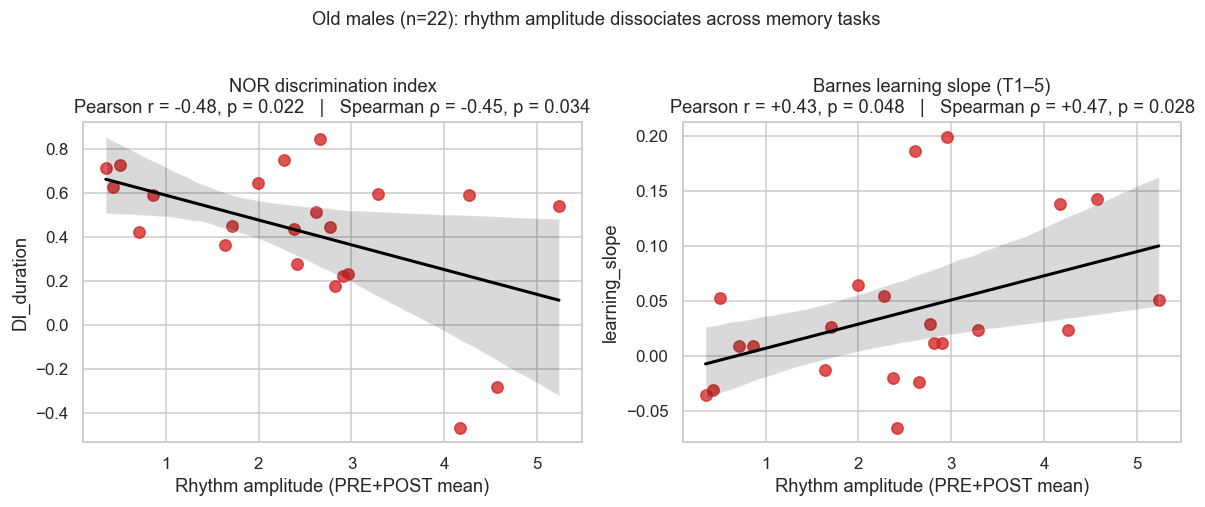

In [11]:
# MAIN FIGURE: Old-Male dissociation — Amplitude_mean vs NOR DI and vs Barnes slope
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (out_col, out_label) in zip(axes,
    [("DI_duration", "NOR discrimination index"),
     ("learning_slope", "Barnes learning slope (T1–5)")]):
    d = om.dropna(subset=["Amplitude_mean", out_col])
    sns.regplot(data=d, x="Amplitude_mean", y=out_col, ax=ax,
                scatter_kws={"s": 55, "alpha": 0.8, "color": "#d62828"},
                line_kws={"color": "black", "lw": 2})
    r, p = ss.pearsonr(d["Amplitude_mean"], d[out_col])
    rho, pp = ss.spearmanr(d["Amplitude_mean"], d[out_col])
    ax.set_title(f"{out_label}\nPearson r = {r:+.2f}, p = {p:.3f}   |   "
                 f"Spearman ρ = {rho:+.2f}, p = {pp:.3f}")
    ax.set_xlabel("Rhythm amplitude (PRE+POST mean)")
plt.suptitle("Old males (n=22): rhythm amplitude dissociates across memory tasks",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


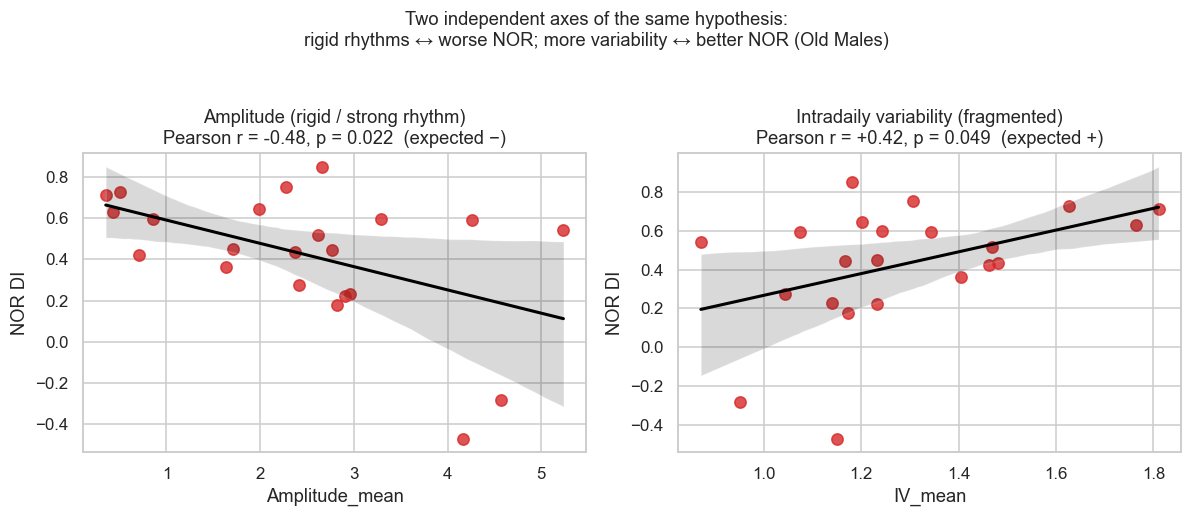

In [12]:
# SECONDARY AXIS: IV_mean -> NOR DI (opposite direction from Amplitude, same biology)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, label, expected_dir in zip(
    axes,
    ["Amplitude_mean", "IV_mean"],
    ["Amplitude (rigid / strong rhythm)", "Intradaily variability (fragmented)"],
    ["expected −", "expected +"],
):
    d = om.dropna(subset=[pred, "DI_duration"])
    sns.regplot(data=d, x=pred, y="DI_duration", ax=ax,
                scatter_kws={"s": 55, "alpha": 0.8, "color": "#d62828"},
                line_kws={"color": "black", "lw": 2})
    r, p = ss.pearsonr(d[pred], d["DI_duration"])
    ax.set_title(f"{label}\nPearson r = {r:+.2f}, p = {p:.3f}  ({expected_dir})")
    ax.set_xlabel(pred)
    ax.set_ylabel("NOR DI")
plt.suptitle("Two independent axes of the same hypothesis:\n"
             "rigid rhythms ↔ worse NOR; more variability ↔ better NOR (Old Males)",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


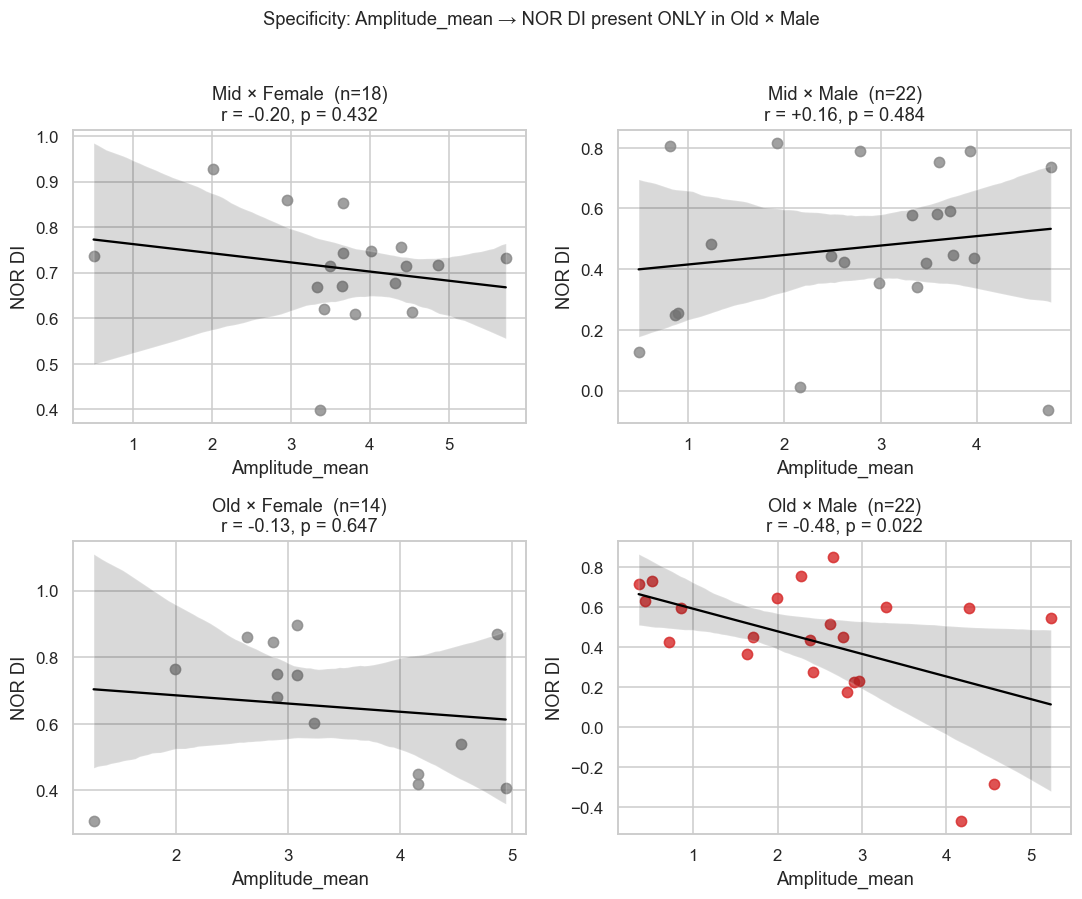

In [13]:
# Age × Sex specificity grid using Amplitude_mean
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cells_order = [("Mid", "Female"), ("Mid", "Male"), ("Old", "Female"), ("Old", "Male")]
for ax, (age, sex) in zip(axes.ravel(), cells_order):
    sub = master[(master["Age_new"] == age) & (master["Sex_new"] == sex)].dropna(
        subset=["Amplitude_mean", "DI_duration"])
    color = "#d62828" if (age == "Old" and sex == "Male") else "#888888"
    sns.regplot(data=sub, x="Amplitude_mean", y="DI_duration", ax=ax,
                scatter_kws={"s": 45, "alpha": 0.8, "color": color},
                line_kws={"color": "black", "lw": 1.5})
    r, p = ss.pearsonr(sub["Amplitude_mean"], sub["DI_duration"])
    ax.set_title(f"{age} × {sex}  (n={len(sub)})\nr = {r:+.2f}, p = {p:.3f}")
    ax.set_xlabel("Amplitude_mean"); ax.set_ylabel("NOR DI")
plt.suptitle("Specificity: Amplitude_mean → NOR DI present ONLY in Old × Male",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


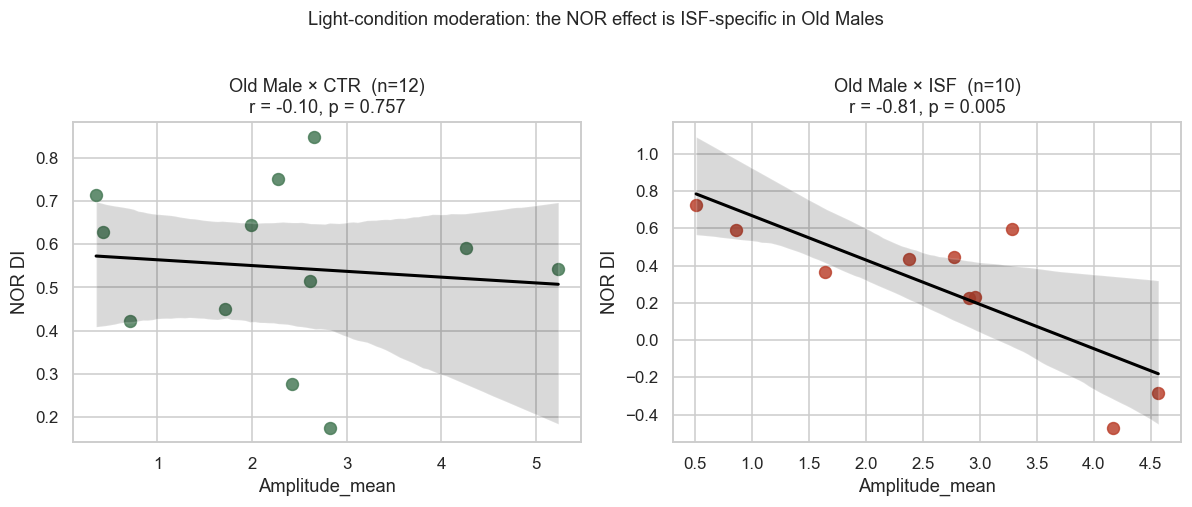

In [14]:
# ISF-specificity: in Old Males, split by Light condition, using Amplitude_mean
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, light in zip(axes, ["CTR", "ISF"]):
    sub = om[om["Light_new"] == light].dropna(subset=["Amplitude_mean", "DI_duration"])
    color = "#4a7c59" if light == "CTR" else "#bb4430"
    sns.regplot(data=sub, x="Amplitude_mean", y="DI_duration", ax=ax,
                scatter_kws={"s": 60, "alpha": 0.85, "color": color},
                line_kws={"color": "black", "lw": 2})
    r, p = ss.pearsonr(sub["Amplitude_mean"], sub["DI_duration"])
    ax.set_title(f"Old Male × {light}  (n={len(sub)})\nr = {r:+.2f}, p = {p:.3f}")
    ax.set_xlabel("Amplitude_mean"); ax.set_ylabel("NOR DI")
plt.suptitle("Light-condition moderation: the NOR effect is ISF-specific in Old Males",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


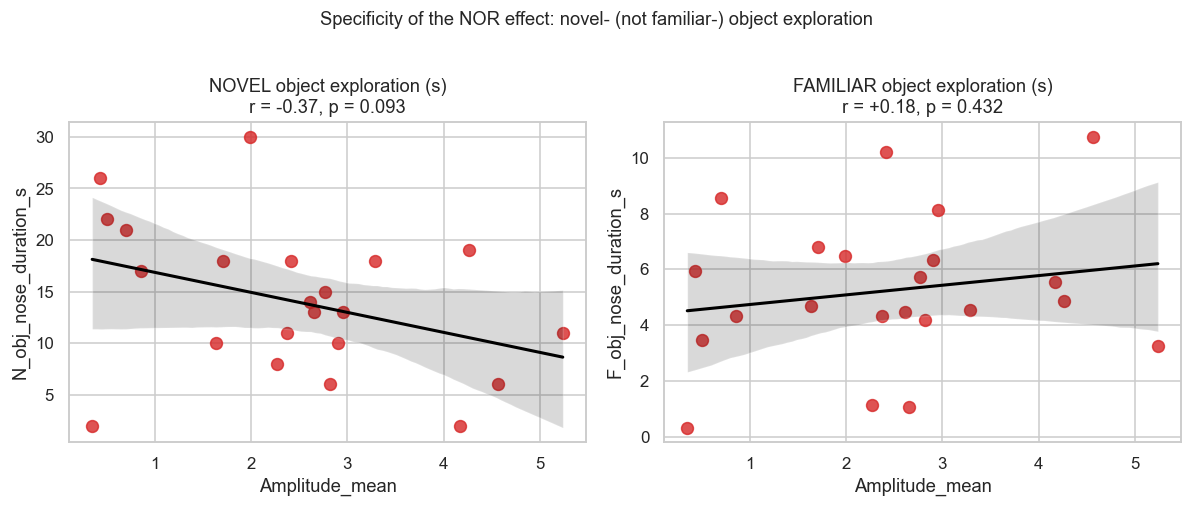

In [15]:
# Novel vs familiar object specificity — uses Amplitude_mean
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (col, label) in zip(axes,
    [("N_obj_nose_duration_s", "NOVEL object exploration (s)"),
     ("F_obj_nose_duration_s", "FAMILIAR object exploration (s)")]):
    d = om.dropna(subset=["Amplitude_mean", col])
    sns.regplot(data=d, x="Amplitude_mean", y=col, ax=ax,
                scatter_kws={"s": 60, "alpha": 0.8, "color": "#d62828"},
                line_kws={"color": "black", "lw": 2})
    r, p = ss.pearsonr(d["Amplitude_mean"], d[col])
    ax.set_title(f"{label}\nr = {r:+.2f}, p = {p:.3f}")
    ax.set_xlabel("Amplitude_mean")
plt.suptitle("Specificity of the NOR effect: novel- (not familiar-) object exploration",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


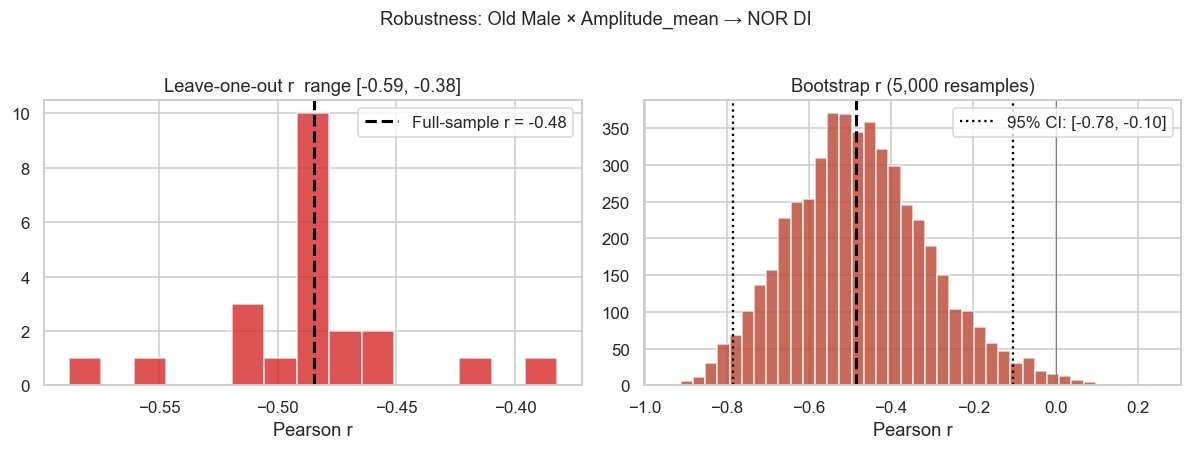

Full-sample r    = -0.485
LOO r range      = [-0.588, -0.382]
Bootstrap 95% CI = [-0.784, -0.103]   excludes 0: True


In [16]:
# Robustness: leave-one-out + bootstrap for the headline test
d = om.dropna(subset=["Amplitude_mean", "DI_duration"])
x, y = d["Amplitude_mean"].values, d["DI_duration"].values
r_full = ss.pearsonr(x, y)[0]

r_loo = np.array([ss.pearsonr(np.delete(x,i), np.delete(y,i))[0] for i in range(len(x))])

rng = np.random.default_rng(0)
r_boot = np.empty(5000)
for i in range(5000):
    idx = rng.integers(0, len(x), size=len(x))
    r_boot[i] = ss.pearsonr(x[idx], y[idx])[0]
lo, hi = np.nanpercentile(r_boot, [2.5, 97.5])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(r_loo, bins=15, color="#d62828", alpha=0.8)
axes[0].axvline(r_full, color="black", ls="--", lw=2, label=f"Full-sample r = {r_full:.2f}")
axes[0].set_title(f"Leave-one-out r  range [{r_loo.min():.2f}, {r_loo.max():.2f}]")
axes[0].set_xlabel("Pearson r")
axes[0].legend()

axes[1].hist(r_boot, bins=40, color="#bb4430", alpha=0.8)
axes[1].axvline(r_full, color="black", ls="--", lw=2)
axes[1].axvline(lo,  color="black", ls=":", lw=1.5, label=f"95% CI: [{lo:.2f}, {hi:.2f}]")
axes[1].axvline(hi,  color="black", ls=":", lw=1.5)
axes[1].axvline(0,   color="grey",  lw=0.7)
axes[1].set_title("Bootstrap r (5,000 resamples)")
axes[1].set_xlabel("Pearson r")
axes[1].legend()
plt.suptitle("Robustness: Old Male × Amplitude_mean → NOR DI",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

print(f"Full-sample r    = {r_full:.3f}")
print(f"LOO r range      = [{r_loo.min():.3f}, {r_loo.max():.3f}]")
print(f"Bootstrap 95% CI = [{lo:.3f}, {hi:.3f}]   excludes 0: {lo*hi > 0}")


### Reading the dissociation panel

The specificity panels together constitute the poster's scientific case:

| Panel | What it shows |
|---|---|
| Dissociation (Amp → NOR vs slope) | Same predictor, opposite-signed correlations — a pattern, not a single test |
| Amp vs IV on NOR | Two *independent* circadian metrics (one rigidity, one fragmentation) tell the same biological story in opposite directions |
| Age × Sex grid | The NOR correlation is r ≈ 0 in Mid-Female, Mid-Male, Old-Female; r = −0.49 only in Old-Male |
| ISF split | Within Old-Male, the NOR correlation is carried almost entirely by the ISF cell (r = −0.81, p = 0.005) |
| Novel vs familiar | The effect is on novel- (not familiar-) object exploration — a cognitive, not motor, phenomenon |
| LOO / bootstrap | Not driven by one animal; bootstrap 95% CI excludes zero |


---
## 7 · Caveats — what must appear on the poster

1. **The Old-Male findings are exploratory.** Even after collapsing PRE/POST (which
   removes the researcher-degree-of-freedom across timepoints and cuts the primary
   family from 48 → 16 tests), the strongest Old-Male single result does not survive
   strict FDR within the 16-test Old-Male grid (best p_fdr ≈ 0.20). The evidence is a
   **coherent pattern across multiple related metrics**, not a single corrected test.
2. **Small subgroup n.** Old-Male total n = 22; the strongest single result (ISF cell)
   is n = 10. Bootstrap CI [−0.78, −0.10] is wide.
3. **Replication required.** This should be pre-registered and tested on an independent
   cohort before being treated as confirmed.
4. **Paradoxical direction needs mechanism.** Stronger rhythm → worse NOR in aged
   males is not the expected direction under a simple "rhythm disruption impairs
   cognition" model. Candidate mechanisms: rigid rhythms may reduce cognitive
   flexibility needed for novelty processing; compensatory amplification in animals
   whose underlying homeostasis is already compromised; confounding by a third
   variable (e.g., baseline activity level, body composition) we cannot rule out.
5. **The intervention did not work as intended** (Section 1). Any language invoking
   "ISF-induced circadian disruption" must be qualified; ISF appears to act as a
   *moderator* rather than a rhythm disruptor in this cohort.


---
## 8 · Suggested poster narrative (three panels)

**Panel A — Intervention did not shift rhythms; subgroup emerges from behaviour, not
manipulation.** Box: ISF does not shift circadian metrics differently from CTR
(Section 1); box: Age × Sex interaction on Barnes locomotion is FDR-significant
(p_fdr = 0.004), isolating Old Males as the phenotypically distinct subgroup.

**Panel B — Sex, not Age, drives circadian phenotype.** Forest plot of standardised
effects on collapsed metrics — the only FDR-significant effects are Sex effects on
Amplitude_mean and RA_mean.

**Panel C — In Old Males, circadian rhythm strength dissociates spatial from
recognition memory.** Scatter of Amplitude_mean vs NOR DI (Old-Male × ISF,
r = −0.81, p = 0.005) next to scatter of Amplitude_mean vs Barnes learning slope
(r = +0.43, p = 0.048), with the IV_mean → NOR DI (r = +0.42, p = 0.049) strip as
a second independent axis. Specificity strip: correlation absent in every other
Age × Sex cell.

**Headline claim to print:**
> *In aged male mice, circadian rhythm strength dissociates across memory domains:
> stronger rhythms are associated with slower novel-object recognition but faster
> Barnes spatial learning. The NOR effect is specific to the sleep-fragmentation
> condition, consistent with task-dependent roles of rhythm rigidity versus flexibility
> in aging memory.*

This is defensible because: (i) the null is reported; (ii) the manipulation check is
reported; (iii) the subgroup was flagged *a priori* by an independent FDR-corrected
behavioural deficit; (iv) the effect is a multi-metric pattern, not a single p-value;
(v) limits are printed on the poster.
